In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
df1 = pd.read_csv(r"F:\DATA SCIENCE\Projects\Global Literacy & Educational Trends\data\raw\df_literacy.csv", index_col = 0)
df2 = pd.read_csv(r"F:\DATA SCIENCE\Projects\Global Literacy & Educational Trends\data\raw\df_illiteracy.csv", index_col = 0)
df3 = pd.read_csv(r"F:\DATA SCIENCE\Projects\Global Literacy & Educational Trends\data\raw\df_gdp_schooling.csv", index_col = 0)

In [3]:
pd.set_option("display.max_rows", None)

# Filtering

## df_literacy dataset

In [4]:
df1["year"] = pd.to_numeric(df1["year"], errors = 'coerce')

df1 = df1[(df1["year"] >= 1990) & (df1["year"] <= 2023)]
print(df1.shape)

(1712, 7)


In [5]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1712 entries, 1 to 2018
Data columns (total 7 columns):
 #   Column                                                                     Non-Null Count  Dtype  
---  ------                                                                     --------------  -----  
 0   entity                                                                     1712 non-null   object 
 1   code                                                                       1148 non-null   object 
 2   year                                                                       1712 non-null   int64  
 3   adult_literacy_rate__population_15plus_years__both_sexes__pct__lr_ag15t99  1420 non-null   float64
 4   youth_literacy_rate__population_15_24_years__male__pct__lr_ag15t24_m       1620 non-null   float64
 5   youth_literacy_rate__population_15_24_years__female__pct__lr_ag15t24_f     1697 non-null   float64
 6   owid_region                                                   

## df_illiteracy

In [6]:
df2["year"] = pd.to_numeric(df2["year"], errors = 'coerce')

df2 = df2[(df2["year"] >= 1990) & (df2["year"] <= 2023)]
df2.shape

(1419, 5)

In [7]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1419 entries, 2 to 2058
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   entity           1419 non-null   object 
 1   code             867 non-null    object 
 2   year             1419 non-null   int64  
 3   illiteracy_rate  1419 non-null   float64
 4   literacy_rate    1419 non-null   float64
dtypes: float64(2), int64(1), object(2)
memory usage: 66.5+ KB


## df_gdp_schooling

In [8]:
df3["year"] = pd.to_numeric(df3["year"], errors = 'coerce')

df3 = df3[(df3["year"] >= 1990) & (df3['year'] <= 2024)]
df3.shape

(7884, 8)

In [9]:
df3.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7884 entries, 25 to 11112
Data columns (total 8 columns):
 #   Column                                                        Non-Null Count  Dtype  
---  ------                                                        --------------  -----  
 0   entity                                                        7884 non-null   object 
 1   code                                                          7295 non-null   object 
 2   year                                                          7884 non-null   int64  
 3   ny_gdp_pcap_pp_kd                                             7240 non-null   float64
 4   owid_region                                                   6840 non-null   object 
 5   literacy_rate                                                 1385 non-null   float64
 6   mf_youth_and_adults__15_64_years__average_years_of_education  884 non-null    float64
 7   population_historical                                         1686 non-nu

# Standardization

## Standardize Column Names

### df_literacy

In [10]:
df1 = df1.rename(columns = {
    "entity" : "country",
    "adult_literacy_rate__population_15plus_years__both_sexes__pct__lr_ag15t99" : "adult_literacy_rate",
    "youth_literacy_rate__population_15_24_years__male__pct__lr_ag15t24_m" : "youth_literacy_rate_M",
    "youth_literacy_rate__population_15_24_years__female__pct__lr_ag15t24_f" : "youth_literacy_rate_F",
    "owid_region" : "continent"
})
df1.columns

Index(['country', 'code', 'year', 'adult_literacy_rate',
       'youth_literacy_rate_M', 'youth_literacy_rate_F', 'continent'],
      dtype='object')

### df_illiteracy

In [11]:
df2 = df2.rename(columns = {"entity" : "country"})
df2.columns

Index(['country', 'code', 'year', 'illiteracy_rate', 'literacy_rate'], dtype='object')

### df_gdp_schooling

In [12]:
df3 = df3.rename(columns = {
    "entity" : "country",
    "ny_gdp_pcap_pp_kd" : "gdp",
    "owid_region" : "continent",
    "mf_youth_and_adults__15_64_years__average_years_of_education" : "avg_schooling_years",
    "population_historical" : "population"
})
df3.columns

Index(['country', 'code', 'year', 'gdp', 'continent', 'literacy_rate',
       'avg_schooling_years', 'population'],
      dtype='object')

## Remove Aggregates

### df_literacy

In [13]:
print(df1['country'].unique())
# Remove aggregates to avoid distortion in corr, rank and reg.
aggregates = [
    "Central and Southern Asia (SDG)",
    "East Asia and Pacific (WB)",
    "Eastern and South-Eastern Asia (SDG)",
    "Europe and Central Asia (WB)",
    "Europe and Northern America (SDG)",
    "High-income countries",
    "Latin America and Caribbean (WB)",
    "Latin America and the Caribbean (SDG)",
    "Low-income countries",
    "Lower-middle-income countries",
    "Middle East and North Africa (WB)",
    "Middle-income countries",
    "Northern Africa and Western Asia (SDG)",
    "North America (WB)",
    "South Asia (WB)",
    "Sub-Saharan Africa (SDG)",
    "Sub-Saharan Africa (WB)",
    "Oceania (excluding Australia and New Zealand) (SDG)",
    "Upper-middle-income countries",
    "World"
]
df1 = df1[~df1["country"].isin(aggregates)]

# Validating whether all aggregates are removed
set(df1["country"].unique()) & set(aggregates)


['Afghanistan' 'Albania' 'Algeria' 'Angola' 'Antigua and Barbuda'
 'Argentina' 'Armenia' 'Aruba' 'Azerbaijan' 'Bahrain' 'Bangladesh'
 'Barbados' 'Belarus' 'Belize' 'Benin' 'Bhutan' 'Bolivia'
 'Bosnia and Herzegovina' 'Botswana' 'Brazil' 'Brunei' 'Bulgaria'
 'Burkina Faso' 'Burundi' 'Cambodia' 'Cameroon' 'Cape Verde'
 'Cayman Islands' 'Central African Republic'
 'Central and Southern Asia (SDG)' 'Chad' 'Chile' 'China' 'Colombia'
 'Comoros' 'Congo' 'Costa Rica' "Cote d'Ivoire" 'Croatia' 'Cuba' 'Cyprus'
 'Democratic Republic of Congo' 'Djibouti' 'Dominican Republic'
 'East Asia and Pacific (WB)' 'East Timor'
 'Eastern and South-Eastern Asia (SDG)' 'Ecuador' 'Egypt' 'El Salvador'
 'Equatorial Guinea' 'Eritrea' 'Estonia' 'Eswatini' 'Ethiopia'
 'Europe and Central Asia (WB)' 'Europe and Northern America (SDG)' 'Fiji'
 'Gabon' 'Gambia' 'Georgia' 'Ghana' 'Greece' 'Guam' 'Guatemala' 'Guinea'
 'Guinea-Bissau' 'Guyana' 'Haiti' 'High-income countries' 'Honduras'
 'India' 'Indonesia' 'Iran' 'Iraq' 

set()

### df_illiteracy

In [14]:
print(df2["country"].unique())

aggregates = [
    "World",
    "East Asia and Pacific (WB)",
    "Europe and Central Asia (WB)",
    "Latin America and Caribbean (WB)",
    "Middle East and North Africa (WB)",
    "North America (WB)",
    "South Asia (WB)",
    "Sub-Saharan Africa (WB)",
    "Central and Southern Asia (SDG)",
    "Eastern and South-Eastern Asia (SDG)",
    "Europe and Northern America (SDG)",
    "Northern Africa and Western Asia (SDG)",
    "Sub-Saharan Africa (SDG)",
    "Latin America and the Caribbean (SDG)",
    "Oceania (excluding Australia and New Zealand) (SDG)",
    "Low-income countries",
    "Lower-middle-income countries",
    "Middle-income countries",
    "Upper-middle-income countries"
]
df2 = df2[~df2["country"].isin(aggregates)]

set(df2["country"].unique()) & set(aggregates)

['Afghanistan' 'Albania' 'Algeria' 'Angola' 'Antigua and Barbuda'
 'Argentina' 'Armenia' 'Aruba' 'Azerbaijan' 'Bahrain' 'Bangladesh'
 'Belarus' 'Belize' 'Benin' 'Bhutan' 'Bolivia' 'Bosnia and Herzegovina'
 'Botswana' 'Brazil' 'Brunei' 'Bulgaria' 'Burkina Faso' 'Burundi'
 'Cambodia' 'Cameroon' 'Cape Verde' 'Cayman Islands'
 'Central African Republic' 'Central and Southern Asia (SDG)' 'Chad'
 'Chile' 'China' 'Colombia' 'Comoros' 'Congo' 'Costa Rica' "Cote d'Ivoire"
 'Croatia' 'Cuba' 'Cyprus' 'Democratic Republic of Congo'
 'Dominican Republic' 'East Asia and Pacific (WB)' 'East Timor'
 'Eastern and South-Eastern Asia (SDG)' 'Ecuador' 'Egypt' 'El Salvador'
 'Equatorial Guinea' 'Eritrea' 'Estonia' 'Eswatini' 'Ethiopia'
 'Europe and Central Asia (WB)' 'Europe and Northern America (SDG)'
 'Gabon' 'Gambia' 'Georgia' 'Ghana' 'Greece' 'Guam' 'Guatemala' 'Guinea'
 'Guinea-Bissau' 'Guyana' 'Haiti' 'Honduras' 'India' 'Indonesia' 'Iran'
 'Iraq' 'Italy' 'Jamaica' 'Jordan' 'Kazakhstan' 'Kenya' 'Kirib

set()

### df_gdp_schooling

In [15]:
print(df3["country"].unique())

aggregates = [
    "World", "Africa", "Asia", "Europe",
    "North America", "South America", "Oceania",
    "East Asia and Pacific (WB)",
    "Europe and Central Asia (WB)",
    "Latin America and Caribbean (WB)",
    "Middle East and North Africa (WB)",
    "Middle East, North Africa, Afghanistan and Pakistan (WB)",
    "North America (WB)",
    "South Asia (WB)",
    "Sub-Saharan Africa (WB)",
    "Central and Southern Asia (SDG)",
    "Eastern and South-Eastern Asia (SDG)",
    "Europe and Northern America (SDG)",
    "Northern Africa and Western Asia (SDG)",
    "Latin America and the Caribbean (SDG)",
    "Oceania (excluding Australia and New Zealand) (SDG)",
    "Sub-Saharan Africa (SDG)",
    "High-income countries",
    "Low-income countries",
    "Lower-middle-income countries",
    "Middle-income countries",
    "Upper-middle-income countries",
    "European Union (27)"
]

df3 = df3[~df3["country"].isin(aggregates)].copy()

set(df3["country"].unique()) & set(aggregates)


['Afghanistan' 'Africa' 'Albania' 'Algeria' 'Andorra' 'Angola'
 'Antigua and Barbuda' 'Argentina' 'Armenia' 'Aruba' 'Asia' 'Australia'
 'Austria' 'Azerbaijan' 'Bahamas' 'Bahrain' 'Bangladesh' 'Barbados'
 'Belarus' 'Belgium' 'Belize' 'Benin' 'Bermuda' 'Bhutan' 'Bolivia'
 'Bosnia and Herzegovina' 'Botswana' 'Brazil' 'Brunei' 'Bulgaria'
 'Burkina Faso' 'Burundi' 'Cambodia' 'Cameroon' 'Canada' 'Cape Verde'
 'Cayman Islands' 'Central African Republic'
 'Central and Southern Asia (SDG)' 'Chad' 'Chile' 'China' 'Colombia'
 'Comoros' 'Congo' 'Costa Rica' "Cote d'Ivoire" 'Croatia' 'Cuba' 'Curacao'
 'Cyprus' 'Czechia' 'Democratic Republic of Congo' 'Denmark' 'Djibouti'
 'Dominica' 'Dominican Republic' 'East Asia and Pacific (WB)' 'East Timor'
 'Eastern and South-Eastern Asia (SDG)' 'Ecuador' 'Egypt' 'El Salvador'
 'Equatorial Guinea' 'Eritrea' 'Estonia' 'Eswatini' 'Ethiopia' 'Europe'
 'Europe and Central Asia (WB)' 'Europe and Northern America (SDG)'
 'European Union (27)' 'Faroe Islands' 'Fiji' 

set()

## Standardize Region Mapping

### df_literacy

In [16]:
print(df1["continent"].unique())

df1[df1["continent"].isnull()]["country"].unique()

['Asia' 'Europe' 'Africa' nan 'South America' 'North America' 'Oceania']


array(['Antigua and Barbuda', 'East Timor', 'Iran', 'Mali', 'Mauritius',
       'Morocco', 'Nauru', 'Rwanda', 'Solomon Islands', 'Vanuatu'],
      dtype=object)

In [17]:
missing_continent_map = {
    "Antigua and Barbuda": "North America",
    "East Timor": "Asia",
    "Iran": "Asia",
    "Mali": "Africa",
    "Mauritius": "Africa",
    "Morocco": "Africa",
    "Nauru": "Oceania",
    "Rwanda": "Africa",
    "Solomon Islands": "Oceania",
    "Vanuatu": "Oceania"
}

df1.loc[df1["country"].isin(missing_continent_map.keys()), "continent"] = df1["country"].map(missing_continent_map)

In [18]:
df1[df1["continent"].isnull()]["country"].unique()

array([], dtype=object)

### df_gdp_schooling

In [19]:
df3["continent"].unique()

array(['Asia', 'Europe', 'Africa', 'North America', 'South America',
       'Oceania'], dtype=object)

# Handling Missing Values

## Literacy Missing

### adult_literacy_rate

In [20]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1114 entries, 1 to 2018
Data columns (total 7 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   country                1114 non-null   object 
 1   code                   1114 non-null   object 
 2   year                   1114 non-null   int64  
 3   adult_literacy_rate    834 non-null    float64
 4   youth_literacy_rate_M  1022 non-null   float64
 5   youth_literacy_rate_F  1099 non-null   float64
 6   continent              1114 non-null   object 
dtypes: float64(3), int64(1), object(3)
memory usage: 101.9+ KB


In [21]:
# Checking Distribution
missing_ratio = df1.groupby("country")["adult_literacy_rate"].apply(lambda x: x.isnull().mean())
missing_ratio

country
Afghanistan                     0.250000
Albania                         0.285714
Algeria                         0.250000
Angola                          0.000000
Antigua and Barbuda             0.000000
Argentina                       0.000000
Armenia                         0.142857
Aruba                           0.000000
Azerbaijan                      0.071429
Bahrain                         0.000000
Bangladesh                      0.176471
Barbados                        1.000000
Belarus                         0.400000
Belize                          0.500000
Benin                           0.250000
Bhutan                          0.250000
Bolivia                         0.590909
Bosnia and Herzegovina          0.250000
Botswana                        0.000000
Brazil                          0.375000
Brunei                          0.000000
Bulgaria                        0.000000
Burkina Faso                    0.083333
Burundi                         0.250000
Cambodia

In [22]:
# Dropped ratio > 0.5 and interpolated ratio < 0.5, for corruption free analysis.
countries_to_drop = missing_ratio[(missing_ratio == 1.0) & (missing_ratio > 0.5)].index
df1 = df1[~df1["country"].isin(countries_to_drop)]

df1["adult_literacy_rate"] = (
    df1.groupby("country")["adult_literacy_rate"].transform(lambda X: X.interpolate())
)

# ffill and bfill for edges
df1["adult_literacy_rate"] = (
    df1.groupby("country")["adult_literacy_rate"].transform(lambda X: X.ffill().bfill())
)
df1.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1106 entries, 1 to 2018
Data columns (total 7 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   country                1106 non-null   object 
 1   code                   1106 non-null   object 
 2   year                   1106 non-null   int64  
 3   adult_literacy_rate    1106 non-null   float64
 4   youth_literacy_rate_M  1015 non-null   float64
 5   youth_literacy_rate_F  1091 non-null   float64
 6   continent              1106 non-null   object 
dtypes: float64(3), int64(1), object(3)
memory usage: 69.1+ KB


### youth_literacy_rate

In [23]:
df1["youth_literacy_rate_M"] = (
    df1.groupby("country")["youth_literacy_rate_M"].transform(lambda X: X.interpolate())
)

df1["youth_literacy_rate_F"] = (
    df1.groupby("country")["youth_literacy_rate_F"].transform(lambda X: X.interpolate())
)

df1["youth_literacy_rate_M"] = (
    df1.groupby("country")["youth_literacy_rate_M"].transform(lambda X: X.ffill().bfill())
)

df1["youth_literacy_rate_F"] = (
    df1.groupby("country")["youth_literacy_rate_F"].transform(lambda X: X.ffill().bfill())
)

df1.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1106 entries, 1 to 2018
Data columns (total 7 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   country                1106 non-null   object 
 1   code                   1106 non-null   object 
 2   year                   1106 non-null   int64  
 3   adult_literacy_rate    1106 non-null   float64
 4   youth_literacy_rate_M  1103 non-null   float64
 5   youth_literacy_rate_F  1103 non-null   float64
 6   continent              1106 non-null   object 
dtypes: float64(3), int64(1), object(3)
memory usage: 69.1+ KB


In [24]:
df1[df1["youth_literacy_rate_M"].isna()]

,country,code,year,adult_literacy_rate,youth_literacy_rate_M,youth_literacy_rate_F,continent
22,Antigua and Barbuda,ATG,2001,99.00000,NaN,NaN,North America
1206,Nauru,NRU,2023,96.58654,NaN,NaN,Oceania
1561,Solomon Islands,SLB,1999,77.00000,NaN,NaN,Oceania


In [25]:
# Dropping these rows due to insignificancy
df1 = df1.dropna(subset = ["youth_literacy_rate_M", "youth_literacy_rate_F"])
df1.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1103 entries, 1 to 2018
Data columns (total 7 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   country                1103 non-null   object 
 1   code                   1103 non-null   object 
 2   year                   1103 non-null   int64  
 3   adult_literacy_rate    1103 non-null   float64
 4   youth_literacy_rate_M  1103 non-null   float64
 5   youth_literacy_rate_F  1103 non-null   float64
 6   continent              1103 non-null   object 
dtypes: float64(3), int64(1), object(3)
memory usage: 68.9+ KB


## Missing GDP and Schooling Years

In [26]:
df3.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6840 entries, 25 to 11112
Data columns (total 8 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   country              6840 non-null   object 
 1   code                 6840 non-null   object 
 2   year                 6840 non-null   int64  
 3   gdp                  6785 non-null   float64
 4   continent            6840 non-null   object 
 5   literacy_rate        833 non-null    float64
 6   avg_schooling_years  847 non-null    float64
 7   population           1547 non-null   float64
dtypes: float64(4), int64(1), object(3)
memory usage: 480.9+ KB


In [27]:
df3["gdp"] = (
    df3.groupby("country")["gdp"].transform(lambda x: x.interpolate())
)

df3["gdp"] = (
    df3.groupby("country")["gdp"].transform(lambda x: x.ffill().bfill())
)

In [28]:
missing_ratio = df3.groupby("country")["avg_schooling_years"].apply(lambda X: X.isnull().mean())
countries_to_drop = missing_ratio[missing_ratio == 1.0].index
df3 = df3[~df3["country"].isin(countries_to_drop)]

In [29]:
df3.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4963 entries, 25 to 11112
Data columns (total 8 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   country              4963 non-null   object 
 1   code                 4963 non-null   object 
 2   year                 4963 non-null   int64  
 3   gdp                  4919 non-null   float64
 4   continent            4963 non-null   object 
 5   literacy_rate        671 non-null    float64
 6   avg_schooling_years  847 non-null    float64
 7   population           1385 non-null   float64
dtypes: float64(4), int64(1), object(3)
memory usage: 349.0+ KB


In [30]:
df3["avg_schooling_years"] = (
    df3.groupby("country")["avg_schooling_years"].transform(lambda x: x.interpolate())
)

df3["avg_schooling_years"] = (
    df3.groupby("country")["avg_schooling_years"].transform(lambda x: x.ffill().bfill())
)

In [31]:
df3.drop('literacy_rate', axis = 1, inplace = True)
df3.drop("population", axis = 1, inplace = True)

# Deduplication

## df_literacy

In [32]:
df1[df1.duplicated(subset = ["country", "year"], keep = False)].sort_values(["country", "year"])
df1.duplicated(subset=["country", "year"]).sum()

np.int64(0)

## df_illiteracy

In [33]:
df2[df2.duplicated(subset = ["country", "year"], keep = False)].sort_values(["country", "year"])
df2.duplicated(subset=["country", "year"]).sum()

np.int64(0)

## df_gdp_schooling

In [34]:
df3[df3.duplicated(subset = ["country", "year"], keep = False)].sort_values(["country", "year"])
df3.duplicated(subset=["country", "year"]).sum()

np.int64(0)

# Validate Logical Constraints

## Literacy Rates

In [35]:
# Literacy must be between 0 and 100
df1['invalid_literacy_flag'] = (
    (df1['adult_literacy_rate'] < 0) |
    (df1['adult_literacy_rate'] > 100)
)
df1['invalid_literacy_flag'].sum()

np.int64(0)

In [36]:
df1['invalid_literacy_flag'] = (
    (df1['youth_literacy_rate_M'] < 0)  |
    (df1['youth_literacy_rate_M'] > 100)
)
df1['invalid_literacy_flag'].sum()

np.int64(0)

In [37]:
df1['invalid_literacy_flag'] = (
    (df1['youth_literacy_rate_F'] < 0)  |
    (df1['youth_literacy_rate_F'] > 100)
)
df1['invalid_literacy_flag'].sum()

np.int64(0)

In [38]:
df2['invalid_literacy_flag'] = (
    (df2['literacy_rate'] < 0)  |
    (df2['literacy_rate'] > 100)
)
df2['invalid_literacy_flag'].sum()

np.int64(0)

In [39]:
df2['invalid_literacy_flag'] = (
    (df2['illiteracy_rate'] < 0)  |
    (df2['illiteracy_rate'] > 100)
)
df2['invalid_literacy_flag'].sum()

np.int64(0)

## GDP & Schooling Years

In [40]:
# GDP cannot be negative
df3['invalid_gdp_flag'] = (
    df3['gdp'] < 0
)
df3['invalid_gdp_flag'].sum()

np.int64(0)

In [41]:
# Schooling years should not be negative
df3['invalid_schooling_flag'] = (
    df3['avg_schooling_years'] < 0
)
df3['invalid_schooling_flag'].sum()

np.int64(0)

# Outlier Detection

## Z-Score for GDP

1.8005568874023081


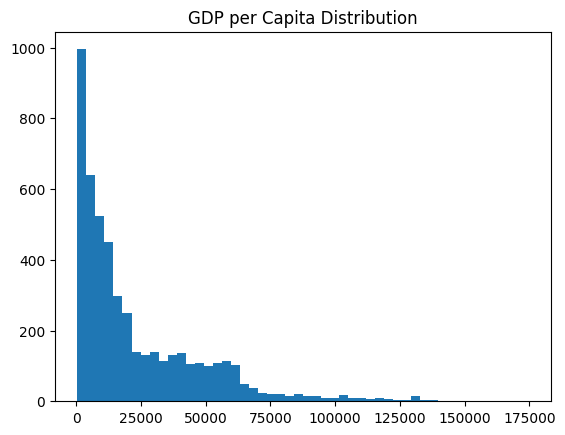

In [42]:
# Checking skewness of GDP column
gdp_skewness = df3['gdp'].skew()
print(gdp_skewness)

plt.hist(df3["gdp"].dropna(), bins = 50)
plt.title("GDP per Capita Distribution")
plt.show()


In [43]:
# Since skewness > 1.5, Z-Score assumption is violated, Hence used log transformation
df3["log_gdp"] = np.log(df3["gdp"])
df3["log_gdp"].skew()

np.float64(-0.21910623081867342)

In [44]:
# Now Outlier Detection using Z-Score
mean_log = df3["log_gdp"].mean()
std_log = df3["log_gdp"].std()

df3["log_gdp_zscore"] = ((df3["log_gdp"] - mean_log) / std_log)

# Flag Extreme GDP Values
df3["gdp_outlier_flag"] = df3["log_gdp_zscore"].abs() > 3
df3["gdp_outlier_flag"].sum()

np.int64(0)

## Literacy Outlier Detection

In [45]:
# Literacy is bounded (0–100).
def detect_iqr_outliers(df, column_name, visualize = True):

    data = df[column_name]

    # Calculate IQR
    Q1 = data.quantile(0.25)
    Q3 = data.quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    flag_col = column_name + "_outlier_flag"

    df[flag_col] = (
        (df[column_name] < lower_bound) |
        (df[column_name] > upper_bound)
    )

    outlier_count = df[flag_col].sum()

    # Visualization
    if visualize:
        plt.figure()
        plt.boxplot(data)
        plt.title(f"Boxplot of {column_name}")
        plt.ylabel(column_name)
        plt.show()

    return outlier_count

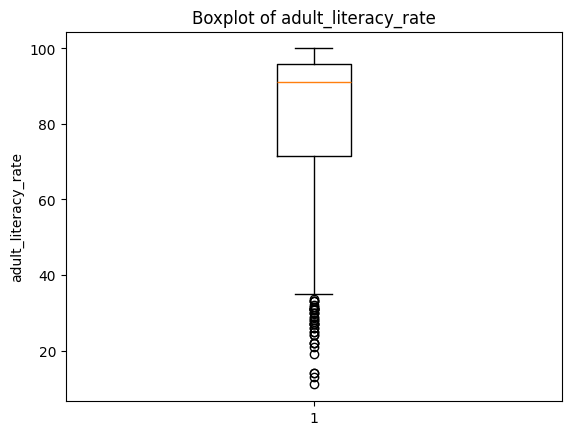

np.int64(40)

In [46]:
detect_iqr_outliers(df1, "adult_literacy_rate")

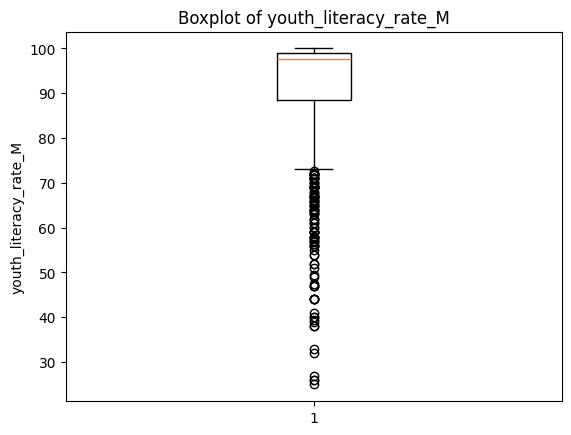

np.int64(107)

In [47]:
detect_iqr_outliers(df1, "youth_literacy_rate_M")

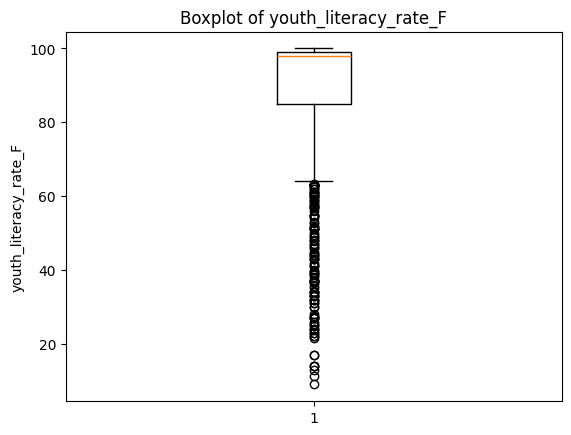

np.int64(130)

In [48]:
detect_iqr_outliers(df1, "youth_literacy_rate_F")

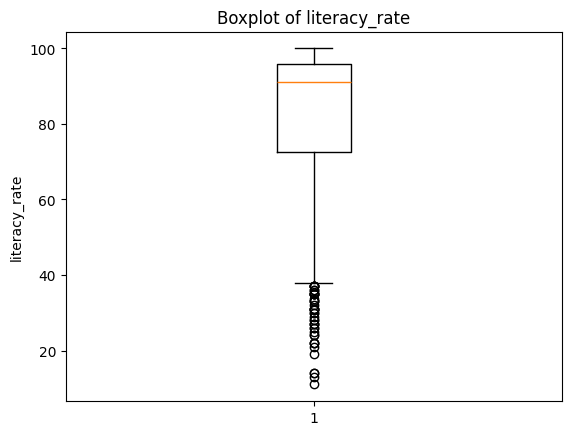

np.int64(45)

In [49]:
detect_iqr_outliers(df2, "literacy_rate")

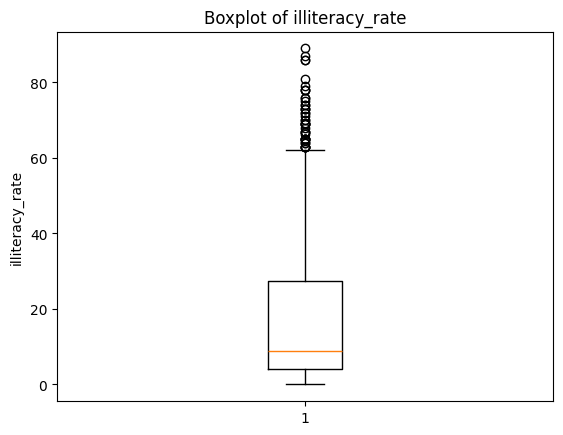

np.int64(45)

In [50]:
detect_iqr_outliers(df2, "illiteracy_rate")

In [51]:
outlier_summary = {
    "Adult": detect_iqr_outliers(df1, "adult_literacy_rate", visualize = False),
    "Female": detect_iqr_outliers(df1, "youth_literacy_rate_F", visualize = False),
    "Male": detect_iqr_outliers(df1, "youth_literacy_rate_M", visualize = False),
    "Literate": detect_iqr_outliers(df2, "literacy_rate", visualize = False),
    "Illiterate": detect_iqr_outliers(df2, "illiteracy_rate", visualize = False)
}
print(outlier_summary)

{'Adult': np.int64(40), 'Female': np.int64(130), 'Male': np.int64(107), 'Literate': np.int64(45), 'Illiterate': np.int64(45)}


In [55]:
# df1.to_csv(r"F:\DATA SCIENCE\Projects\Global Literacy & Educational Trends\data\processed\df_literacy.csv")
df1.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1103 entries, 1 to 2018
Data columns (total 11 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   country                             1103 non-null   object 
 1   code                                1103 non-null   object 
 2   year                                1103 non-null   int64  
 3   adult_literacy_rate                 1103 non-null   float64
 4   youth_literacy_rate_M               1103 non-null   float64
 5   youth_literacy_rate_F               1103 non-null   float64
 6   continent                           1103 non-null   object 
 7   invalid_literacy_flag               1103 non-null   bool   
 8   adult_literacy_rate_outlier_flag    1103 non-null   bool   
 9   youth_literacy_rate_M_outlier_flag  1103 non-null   bool   
 10  youth_literacy_rate_F_outlier_flag  1103 non-null   bool   
dtypes: bool(4), float64(3), int64(1), object(3)
memo

In [53]:
# df2.to_csv(r"F:\DATA SCIENCE\Projects\Global Literacy & Educational Trends\data\processed\df_illiteracy.csv")
df2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 833 entries, 2 to 2058
Data columns (total 8 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   country                       833 non-null    object 
 1   code                          833 non-null    object 
 2   year                          833 non-null    int64  
 3   illiteracy_rate               833 non-null    float64
 4   literacy_rate                 833 non-null    float64
 5   invalid_literacy_flag         833 non-null    bool   
 6   literacy_rate_outlier_flag    833 non-null    bool   
 7   illiteracy_rate_outlier_flag  833 non-null    bool   
dtypes: bool(3), float64(2), int64(1), object(2)
memory usage: 41.5+ KB


In [54]:
# df3.to_csv(r"F:\DATA SCIENCE\Projects\Global Literacy & Educational Trends\data\processed\df_gdp_schooling.csv")
df3.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4963 entries, 25 to 11112
Data columns (total 11 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   country                 4963 non-null   object 
 1   code                    4963 non-null   object 
 2   year                    4963 non-null   int64  
 3   gdp                     4919 non-null   float64
 4   continent               4963 non-null   object 
 5   avg_schooling_years     4963 non-null   float64
 6   invalid_gdp_flag        4963 non-null   bool   
 7   invalid_schooling_flag  4963 non-null   bool   
 8   log_gdp                 4919 non-null   float64
 9   log_gdp_zscore          4919 non-null   float64
 10  gdp_outlier_flag        4963 non-null   bool   
dtypes: bool(3), float64(4), int64(1), object(3)
memory usage: 363.5+ KB
